In [1]:
from mfpy.utils import label_series
from mfpy.clustering import SegmentBasedCluster
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

filename = "../../../data/VDP/V_3D_1ps.dat"
data = np.loadtxt(filename)[:,1:]
data = (data + 180) / 360

In [4]:
data.shape

(250001, 3)

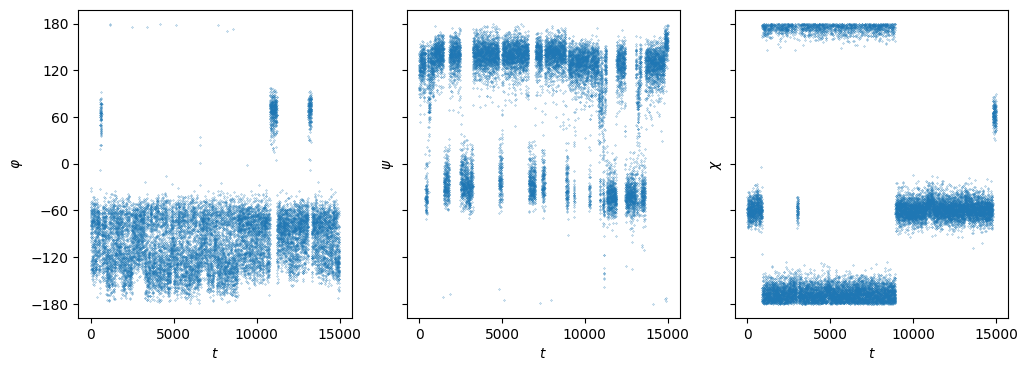

In [23]:
# T = data.shape[0]
T = 15000
l = 0*T
u = 1*T
s=.05
x = data[l:u, :]
h = 4
fig, ax = plt.subplots(1,3, figsize=(3*h, h), sharey=True)
ax[0].scatter(range(u - l), 360*x[l:u,0] - 180, s=s, rasterized=True)
ax[1].scatter(range(u - l), 360*x[l:u,1] - 180, s=s, rasterized=True)
ax[2].scatter(range(u - l), 360*x[l:u,2] - 180, s=s, rasterized=True)
ax[0].set_ylabel(r"$\varphi$")
ax[1].set_ylabel(r"$\psi$")
ax[2].set_ylabel(r"$\chi$")
ax[0].set_xlabel(r"$t$")
ax[1].set_xlabel(r"$t$")
ax[2].set_xlabel(r"$t$")
ticks = [-180, -120, -60, 0, 60, 120, 180]
ax[0].set_yticks(ticks)
plt.savefig("vdp-angles.pdf", bbox_inches="tight")

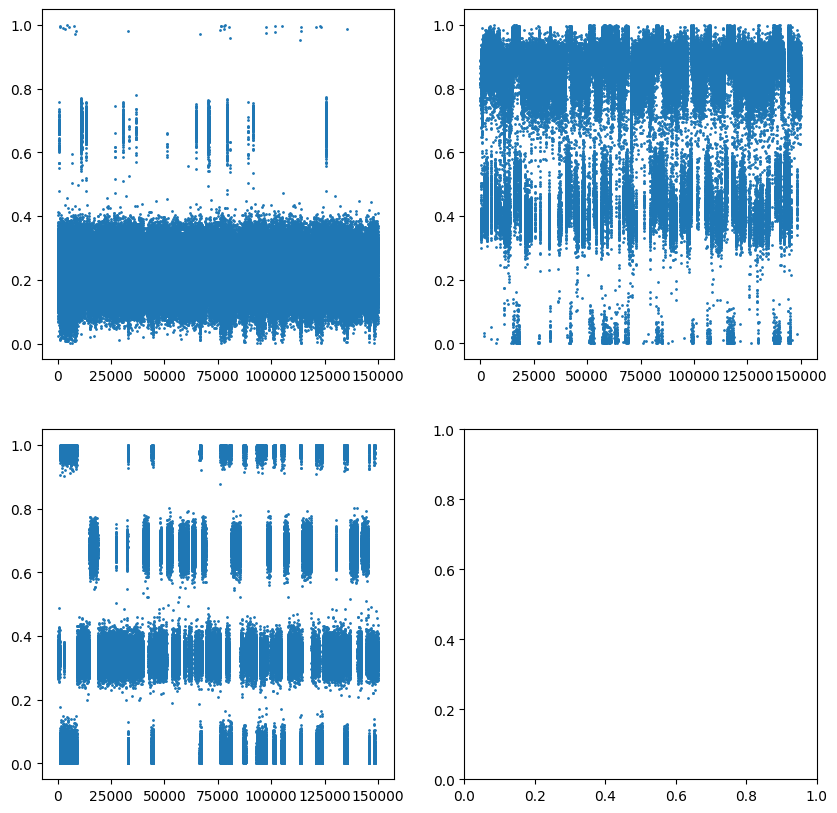

In [27]:
# T = data.shape[0]
T = 50000
l = 0*T
u = 3*T
s=1
x = data[l:u, :]
fig, ax = plt.subplots(2,2, figsize=(10, 10))
ax[0][0].scatter(range(u - l), x[l:u,0], s=s, rasterized=True)
ax[0][1].scatter(range(u - l), x[l:u,1], s=s, rasterized=True)
ax[1][0].scatter(range(u - l), x[l:u,2], s=s, rasterized=True)


In [6]:
data_subset = data[l:u, :]
w = np.array([50,50,50])
q = np.array([0.95, 0.95, 0.95])
sbc = SegmentBasedCluster(window_size=w, quantile=q, periodic=True)
sbc.fit(data_subset)

  2%|▊                                      | 7112/350703 [00:31<37:45, 151.69it/s]/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/ot/lp/solver_1d.py:796: RuntimeWarning: divide by zero encountered in divide
  (Ctp - Ctm + tm * dCptm - tp * dCmtp) / (dCptm - dCmtp)
 73%|██████████████████████████▉          | 255542/350703 [20:05<11:34, 137.05it/s]/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/ot/lp/solver_1d.py:796: RuntimeWarning: invalid value encountered in divide
  (Ctp - Ctm + tm * dCptm - tp * dCmtp) / (dCptm - dCmtp)
100%|█████████████████████████████████████| 350703/350703 [31:56<00:00, 182.95it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(
100%|███████████████████████████████████████| 15225/15225 [01:51<00:00, 136.77it/s]


SegmentBasedCluster(periodic=True, quantile=array([0.95, 0.95, 0.95]),
                    window_size=array([50, 50, 50]))

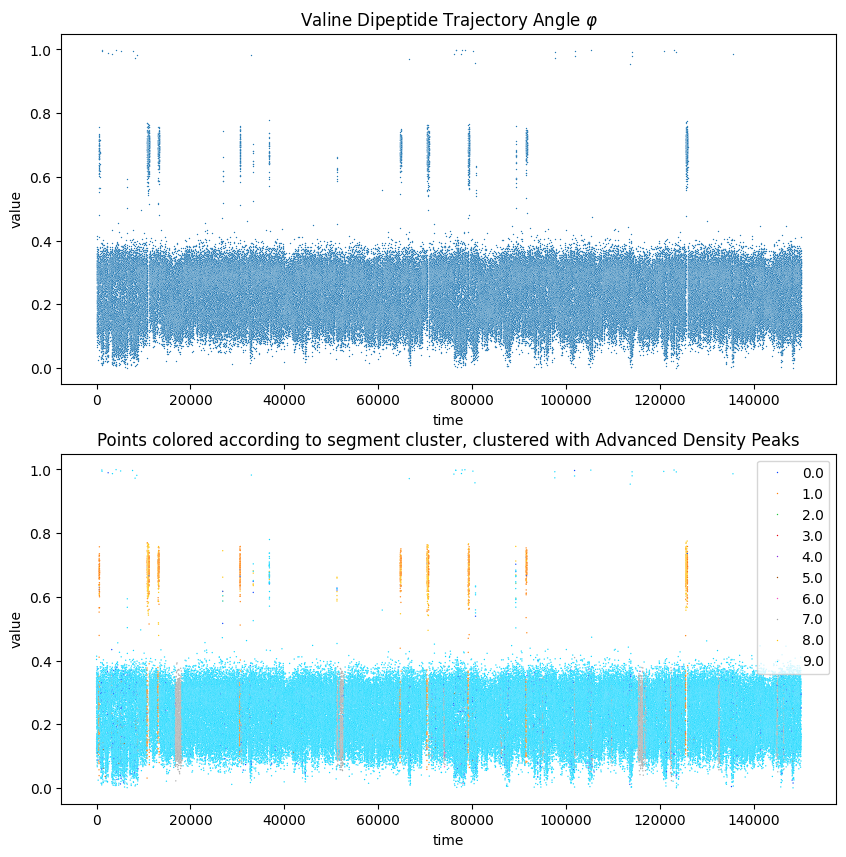

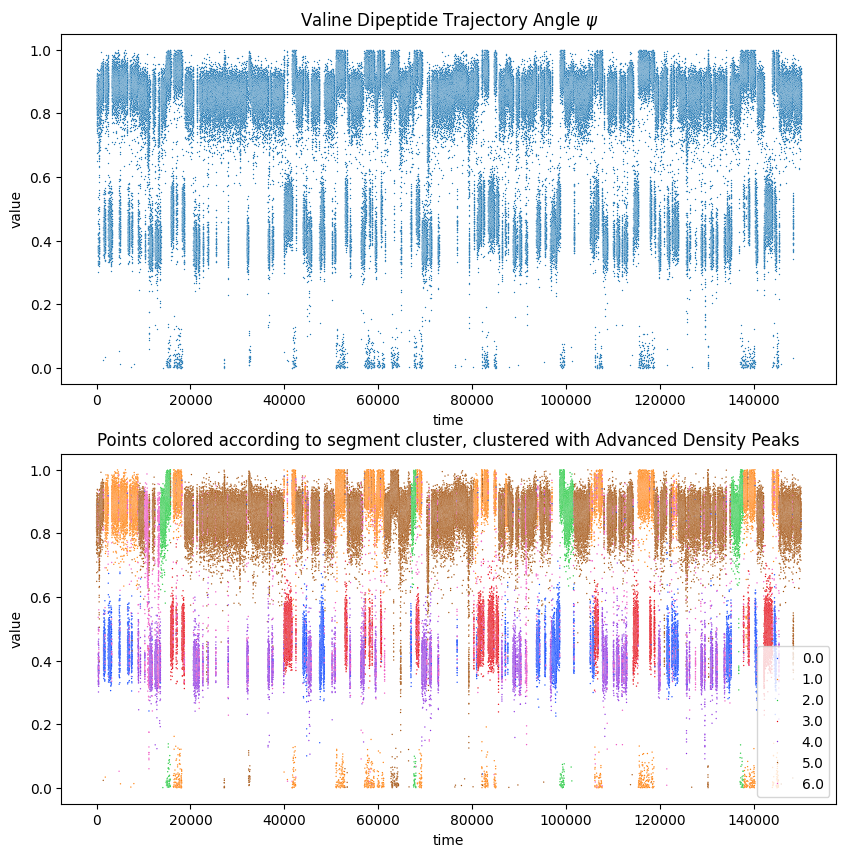

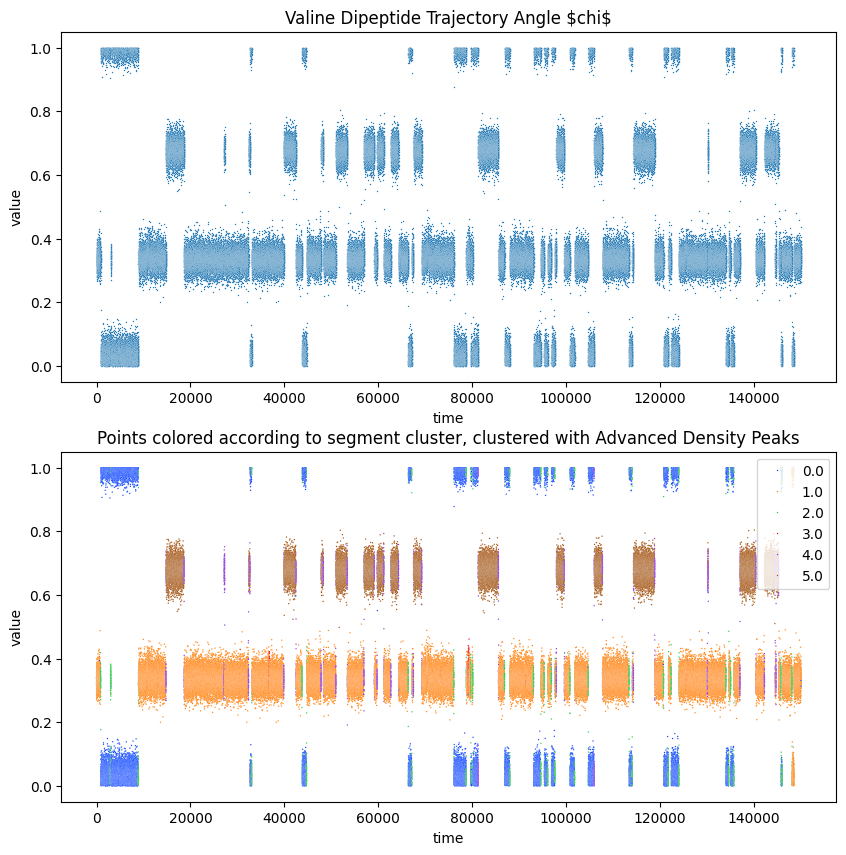

In [7]:
extension="pdf"
ncols = data_subset.shape[1]
angles = [data_subset[:,i] for i in range(ncols)]
cw_labels = [sbc.componentwise_labels_[:,i] for i in range(ncols)]
angle_names=[r"$\varphi$", r"$\psi$", r"\$chi$"]
filenames=[f"vdp-phi.{extension}", f"vdp-psi.{extension}", f"vdp-chi.{extension}"]
locs=["upper right", "lower right", "upper right"]
s = 1
for loc, filename, angle, angle_name, labels in zip(locs, filenames, angles, angle_names, cw_labels):
    df = pd.DataFrame({"time": range(angle.shape[0]), "value": angle, "label": labels})
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    sns.scatterplot(ax=ax[0], data=df, x="time", y="value", s=s, rasterized=True)
    ax[0].set_title(f"Valine Dipeptide Trajectory Angle {angle_name}")
    sns.scatterplot(ax=ax[1], data=df, x="time", y="value", hue="label", palette="bright", s = s, rasterized=True)
    ax[1].set_title("Points colored according to segment cluster, clustered with Advanced Density Peaks")
    plt.legend(loc=loc)
    plt.savefig(filename, bbox_inches="tight")

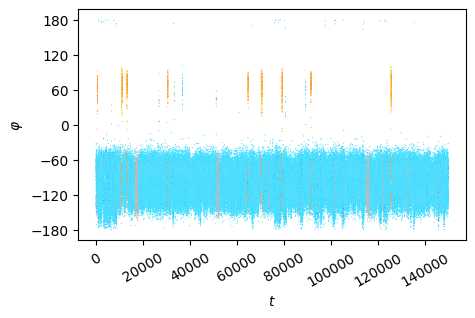

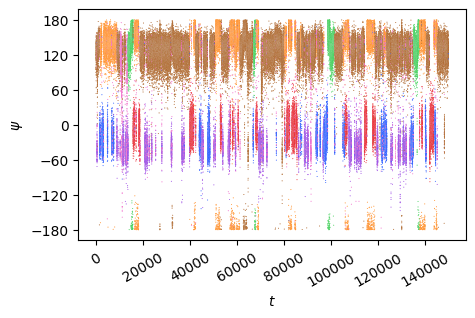

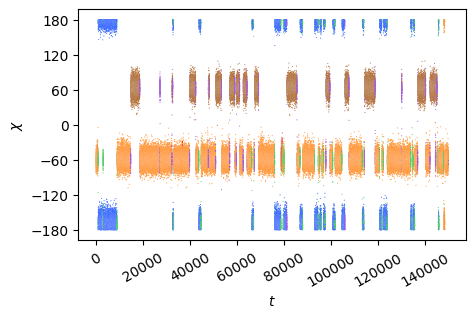

In [43]:
extension="pdf"
ncols = data_subset.shape[1]
angles = [data_subset[:,i] for i in range(ncols)]
cw_labels = [sbc.componentwise_labels_[:,i] for i in range(ncols)]
angle_names=[r"$\varphi$", r"$\psi$", r"$\chi$"]
filenames=[f"vdp-phi.{extension}", f"vdp-psi.{extension}", f"vdp-chi.{extension}"]
locs=["upper right", "lower right", "upper right"]
s = 0.5
for loc, filename, angle, angle_name, labels in zip(locs, filenames, angles, angle_names, cw_labels):
    df = pd.DataFrame({"time": range(angle.shape[0]), "value": 360*angle-180, "label": labels})
    fig, ax = plt.subplots(figsize=(5, 3))
    #sns.scatterplot(ax=ax[0], data=df, x="time", y="value", s=s, rasterized=True)
    #ax[0].set_title(f"Valine Dipeptide Trajectory Angle {angle_name}")
    sns.scatterplot(ax=ax, data=df, x="time", y="value", hue="label", palette="bright", s = s, rasterized=True)
    #ax[1].set_title("Points colored according to segment cluster, clustered with Advanced Density Peaks")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(angle_name)
    ticks = [-180, -120, -60, 0, 60, 120, 180]
    ax.set_yticks(ticks) 
    ax.legend().set_visible(False)
    ax.tick_params(axis='x', rotation=30)
    #plt.legend(loc=loc)
    plt.savefig(filename, bbox_inches="tight")

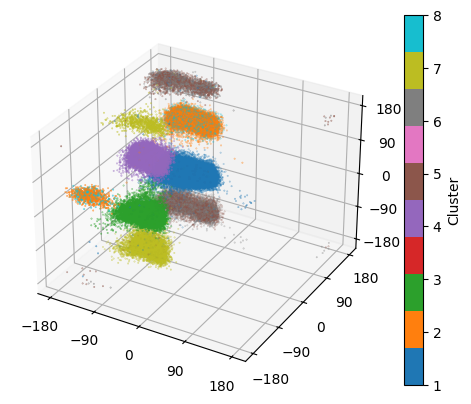

In [45]:
from mpl_toolkits.mplot3d import Axes3D

data_scaled = 360*data[l:u,:] - 180
total = data_scaled.shape[0]
N = 8  # Choose number of clusters to plot
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]
mask = np.isin(labels, top_labels)
fig = plt.figure()
ticks = [-180, -90, 0, 90, 180]
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1], data_scaled[mask, 2], 
                     c=labels[mask], cmap='tab10',s=0.1, rasterized=True)
plt.colorbar(scatter, label='Cluster')
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
plt.savefig("vdp-top-clusters.pdf", bbox_inches="tight")
plt.show()

82.43


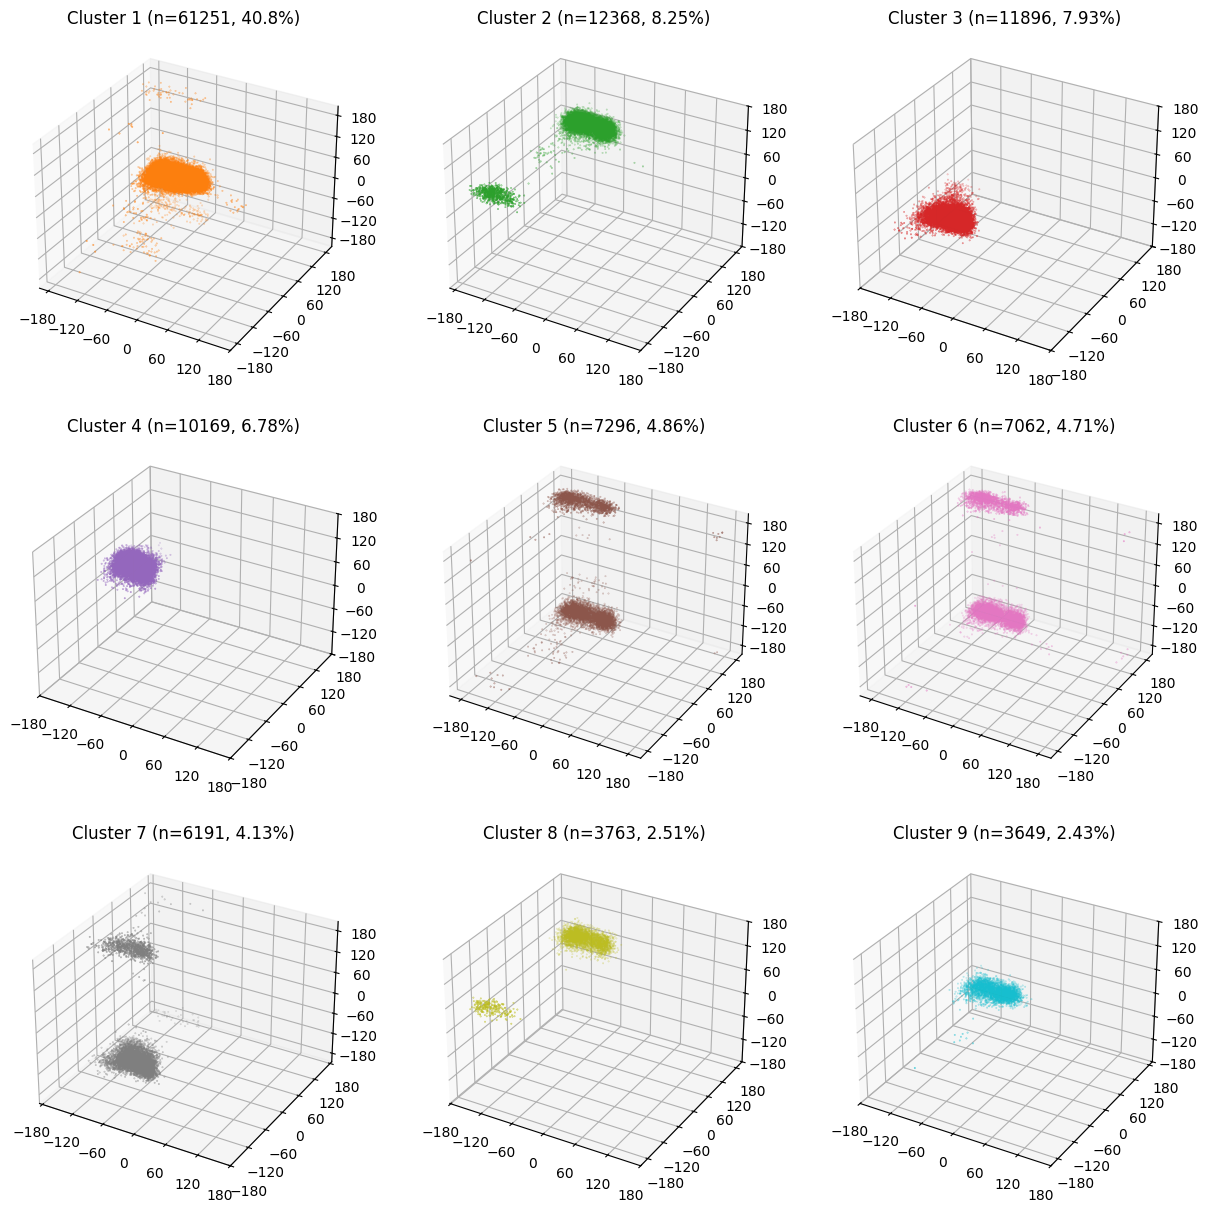

In [44]:
labels = sbc.point_labels_
N = 9  # Choose number of clusters to plot
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]
cmap = plt.cm.tab10
cols = 3
rows = int(np.ceil(N / cols))
fig = plt.figure(figsize=(5*cols, 5*rows))
data_scaled = 360*data[l:u,:] - 180
total = data_scaled.shape[0]
percent = 0

for i, label in enumerate(top_labels):
    ax = fig.add_subplot(rows, cols, i+1, projection='3d')
    mask = labels == label
    this_percent = 100*(np.sum(mask) / total)
    ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1], data_scaled[mask, 2], 
               c=[cmap(label)], s=0.1, rasterized=True)
    ax.set_title(f'Cluster {label} (n={np.sum(mask)}, {this_percent:.3g}%)')
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    percent = percent + this_percent
print(percent)
plt.savefig("vdp-top-individual-clusters.pdf", bbox_inches="tight")

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

data_scaled = 360*data[l:u,:] - 180
total = data_scaled.shape[0]
N = 8  # Choose number of clusters to plot
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]
mask = np.isin(labels, top_labels)
fig = plt.figure()
ticks = [-180, -90, 0, 90, 180]
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1], data_scaled[mask, 2], 
                     c=labels[mask], cmap='tab10',s=0.1, rasterized=True)
plt.colorbar(scatter, label='Cluster')
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
plt.savefig("vdp-top-clusters.pdf", bbox_inches="tight")
plt.show()

labels = sbc.point_labels_
N = 9  # Choose number of clusters to plot
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]
cmap = plt.cm.tab10
cols = 3
rows = int(np.ceil(N / cols))
fig = plt.figure(figsize=(5*cols, 5*rows))
data_scaled = 360*data[l:u,:] - 180
total = data_scaled.shape[0]
percent = 0

for i, label in enumerate(top_labels):
    ax = fig.add_subplot(rows, cols, i+1, projection='3d')
    mask = labels == label
    this_percent = 100*(np.sum(mask) / total)
    ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1], data_scaled[mask, 2], 
               c=[cmap(label)], s=0.1, rasterized=True)
    ax.set_title(f'Cluster {label} (n={np.sum(mask)}, {this_percent:.3g}%)')
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    percent = percent + this_percent
print(percent)
plt.savefig("vdp-top-individual-clusters.pdf", bbox_inches="tight")

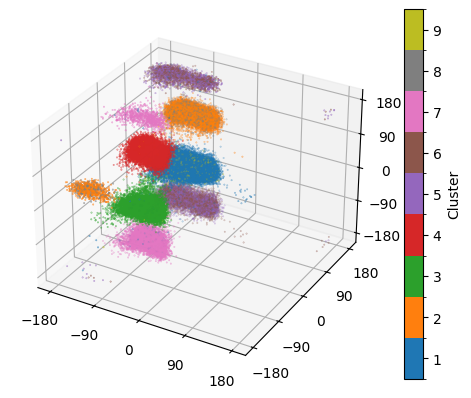

82.43


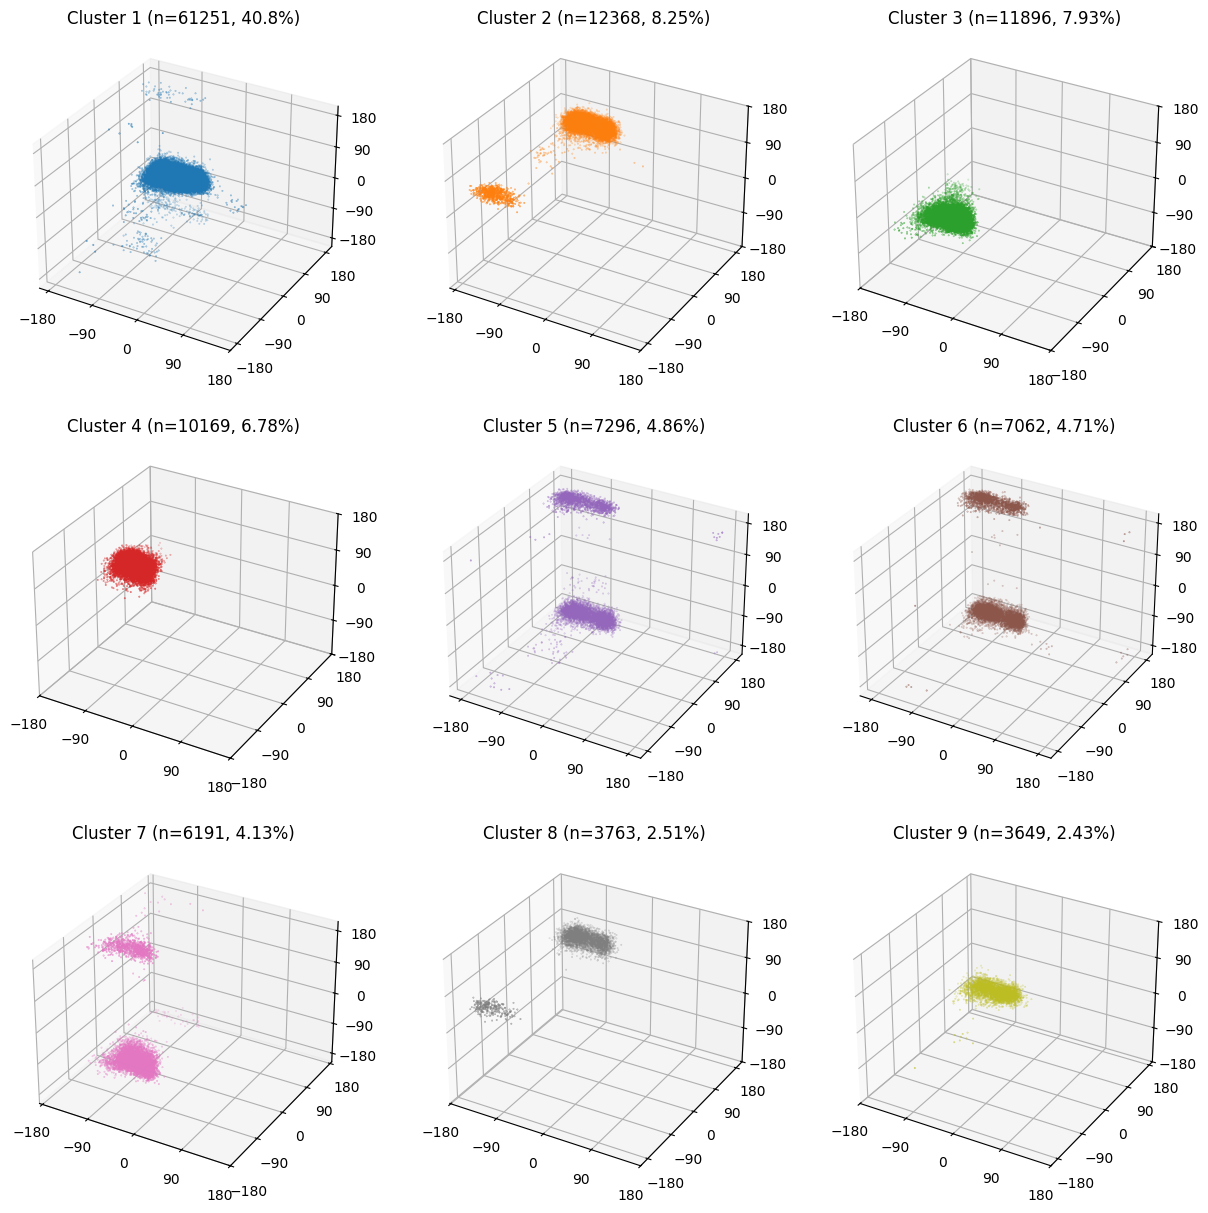

In [47]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap

data_scaled = 360*data[l:u,:] - 180
total = data_scaled.shape[0]
N = 9  # Choose number of clusters to plot
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]

# Create consistent color mapping
cmap = plt.cm.tab10
color_map = {label: cmap(i % 10) for i, label in enumerate(top_labels)}

mask = np.isin(labels, top_labels)
fig = plt.figure()
ticks = [-180, -90, 0, 90, 180]
ax = fig.add_subplot(111, projection='3d')

# Use color_map for consistent colors
colors = [color_map[l] for l in labels[mask]]
scatter = ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1], data_scaled[mask, 2], 
                     c=colors, s=0.1, rasterized=True)

# Create custom colorbar
cmap_list = ListedColormap([color_map[l] for l in top_labels])
bounds = np.arange(N + 1)
norm = BoundaryNorm(bounds, cmap_list.N)
sm = ScalarMappable(cmap=cmap_list, norm=norm)
cbar = plt.colorbar(sm, ax=ax, label='Cluster')
cbar.set_ticks(bounds[:-1] + 0.5)
cbar.set_ticklabels(top_labels)

ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
plt.savefig("vdp-top-clusters.pdf", bbox_inches="tight")
plt.show()

# Individual plots
cols = 3
rows = int(np.ceil(N / cols))
fig = plt.figure(figsize=(5*cols, 5*rows))
percent = 0
for i, label in enumerate(top_labels):
    ax = fig.add_subplot(rows, cols, i+1, projection='3d')
    mask = labels == label
    this_percent = 100*(np.sum(mask) / total)
    # Use same color_map
    ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1], data_scaled[mask, 2], 
               c=[color_map[label]], s=0.1, rasterized=True)
    ax.set_title(f'Cluster {label} (n={np.sum(mask)}, {this_percent:.3g}%)')
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    percent = percent + this_percent
print(percent)
plt.savefig("vdp-top-individual-clusters.pdf", bbox_inches="tight")